#Load Dataset

In [1]:
! git clone https://github.com/Arman-Rayan-Sharif/arman-text-emotion.git

fatal: destination path 'arman-text-emotion' already exists and is not an empty directory.


In [2]:
DATA_PATH = '/content/arman-text-emotion/dataset'

In [3]:
!pip install transformers

In [4]:
import pandas as pd

In [5]:
label_dict = {
  'OTHER': 0,
  'HAPPY': 1,
  'SURPRISE': 2,
  'FEAR': 3,
  'HATE': 4,
  'ANGRY': 5,
  'SAD': 6,
}

In [6]:
train_df = pd.read_table(f'{DATA_PATH}/train.tsv', header=None)
train_df[1] = train_df[1].map(label_dict)
train_texts, train_labels = train_df[0], train_df[1]

test_df = pd.read_table(f'{DATA_PATH}/test.tsv', header=None)
test_df[1] = test_df[1].map(label_dict)
test_texts, test_labels = test_df[0], test_df[1]
data = {
    'train': {'texts': train_texts, 'labels': train_labels},
    'test': {'texts': test_texts, 'labels': test_labels},
}

In [ ]:
proj_test_df = pd.read_table(f'/content/Project_Test - testset.tsv', header=None)
proj_test_df[1] = proj_test_df[1].map(label_dict)


In [7]:
import nltk
nltk.download('stopwords')


In [8]:
import re
from nltk.corpus import stopwords

def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    text = ' '.join([word for word in text.split() if word not in stop_words])

    return text

# Apply the clean_text function to your texts
data['train']['texts'] = data['train']['texts'].apply(clean_text)
data['test']['texts'] = data['test']['texts'].apply(clean_text)


# Train Model

In [9]:
!pip install sentencepiece


In [10]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel, AdamW, get_linear_schedule_with_warmup, RobertaModel, RobertaTokenizer, XLMRobertaTokenizer
from transformers import XLMRobertaModel  # Add this line to import XLMRobertaModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt


In [11]:
class TextClassificationDataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_length):
    self.texts = texts
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_length = max_length

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, idx):
    text = self.texts[idx]
    label = self.labels[idx]
    encoding = self.tokenizer(text, return_tensors='pt', max_length=self.max_length, padding='max_length', truncation=True)
    return {'input_ids': encoding['input_ids'].flatten(), 'attention_mask': encoding['attention_mask'].flatten(), 'label': torch.tensor(label)}

In [12]:
class BERTClassifier(nn.Module):
  def __init__(self, bert_model_name, num_classes):
    super(BERTClassifier, self).__init__()
    self.bert = BertModel.from_pretrained(bert_model_name)
    self.dropout = nn.Dropout(0.1)
    self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

  def forward(self, input_ids, attention_mask):
    outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    pooled_output = outputs.pooler_output
    x = self.dropout(pooled_output)
    logits = self.fc(x)
    return logits

In [13]:
class RobertaClassifier(nn.Module):
  def __init__(self, bert_model_name, num_classes):
    super(RobertaClassifier, self).__init__()
    self.bert = RobertaModel.from_pretrained(bert_model_name)
    self.dropout = nn.Dropout(0.1)
    self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

  def forward(self, input_ids, attention_mask):
    outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    pooled_output = outputs.pooler_output
    x = self.dropout(pooled_output)
    logits = self.fc(x)
    return logits

In [14]:
from transformers import XLMRobertaModel
from torch import nn

class XLMRobertaClassifier(nn.Module):
  def __init__(self, model_name, num_classes):
    super(XLMRobertaClassifier, self).__init__()
    self.bert = XLMRobertaModel.from_pretrained(model_name)
    self.dropout = nn.Dropout(0.1)
    self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

  def forward(self, input_ids, attention_mask):
    outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    pooled_output = outputs.pooler_output
    x = self.dropout(pooled_output)
    logits = self.fc(x)
    return logits



In [15]:
def train(model, data_loader, optimizer, scheduler, device):
  model.train()
  predictions = []
  actual_labels = []
  for batch in tqdm(data_loader, position=0):
    optimizer.zero_grad()
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['label'].to(device)
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    loss = nn.CrossEntropyLoss()(outputs, labels)
    loss.backward()
    optimizer.step()
    scheduler.step()
    _, preds = torch.max(outputs, dim=1)
    predictions.extend(preds.cpu().tolist())
    actual_labels.extend(labels.cpu().tolist())
  return accuracy_score(actual_labels, predictions), classification_report(actual_labels, predictions)


In [16]:
import torch
import torch.nn.functional as F

def predict_emoji(texts, model, tokenizer, device, label_dict, max_length=128):
    model.eval()
    num_classes = len(label_dict)
    preds = torch.zeros(num_classes).to(device)
    linear = torch.nn.Linear(model.fc.in_features, num_classes).to(device)

    for i, text in enumerate(texts):
        encoding = tokenizer(text, return_tensors='pt', max_length=max_length, padding='max_length', truncation=True)
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            preds += torch.sigmoid(logits).sum(dim=0)  # Sum across the num_classes dimension

    preds /= len(texts)

    # Apply softmax for probability-like scores
    preds = F.softmax(preds, dim=0)

    # Use the predicted index directly
    _, label_idx = torch.max(preds, dim=0)
    label = label_dict[label_idx.item()]

    return label, preds.tolist()


In [17]:
def evaluate(model, data_loader, device):
  model.eval()
  predictions = []
  actual_labels = []
  with torch.no_grad():
    for batch in tqdm(data_loader, position=0):
      input_ids = batch['input_ids'].to(device)
      attention_mask = batch['attention_mask'].to(device)
      labels = batch['label'].to(device)
      outputs = model(input_ids=input_ids, attention_mask=attention_mask)
      _, preds = torch.max(outputs, dim=1)
      predictions.extend(preds.cpu().tolist())
      actual_labels.extend(labels.cpu().tolist())
  return accuracy_score(actual_labels, predictions), classification_report(actual_labels, predictions)

In [18]:
num_classes = 7
max_length = 128
batch_size = 16
num_epochs = 5
learning_rate = 2e-5

In [19]:

def main(data, language_model, layer=None, tokenizer_class=BertTokenizer, classifier_class=XLMRobertaClassifier):
    tokenizer = tokenizer_class.from_pretrained(language_model)
    train_dataset = TextClassificationDataset(data['train']['texts'], data['train']['labels'], tokenizer, max_length)
    val_dataset = TextClassificationDataset(data['test']['texts'], data['test']['labels'], tokenizer, max_length)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Create an instance of the classifier class
    model = classifier_class(language_model, num_classes).to(device)

    if layer:
        # freeze bert parameters
        for name, param in model.named_parameters():
            if layer in name:  # classifier layer
                break
            param.requires_grad = False

    optimizer = AdamW(model.parameters(), lr=learning_rate)
    total_steps = len(train_dataloader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

    reports = {'train': list(), 'val': list()}
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        train_accuracy, train_report = train(model, train_dataloader, optimizer, scheduler, device)
        val_accuracy, val_report = evaluate(model, val_dataloader, device)
        print(f"Train Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}")
        print('-' * 20)
        reports['val'].append([val_accuracy, val_report])
        reports['train'].append([train_accuracy, train_report])
    print(val_report)
    return model, reports

In [20]:
!pip install --upgrade pip
# !pip uninstall openai
!pip install openai

!pip install typing_extensions --upgrade


## Using parsbert

*   List item
*   List item



In [21]:
# Set up parameters
# parsbertـlanguge_model = 'HooshvareLab/bert-base-parsbert-uncased'

In [22]:
# parsbertـreports = main(data, parsbertـlanguge_model, layer='11')

In [23]:
# plot_report(parsbertـreports)

In [24]:
!pip install transformers==4.11.3
!pip install sentencepiece



  Using cached transformers-4.11.3-py3-none-any.whl (2.9 MB)
  Using cached sacremoses-0.1.1-py3-none-any.whl.metadata (8.3 kB)
  Using cached tokenizers-0.10.3.tar.gz (212 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached sacremoses-0.1.1-py3-none-any.whl (897 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: Could not build wheels for tokenizers, which is required to install pyproject.toml-based projects


In [25]:
!python --version


Python 3.10.12


In [26]:
xlm_roberta_model = 'xlm-roberta-large'
xlm_roberta_model_instance, xlm_roberta_reports = main(data, xlm_roberta_model, layer='11', tokenizer_class=XLMRobertaTokenizer, classifier_class=XLMRobertaClassifier)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/5


100%|██████████| 72/72 [00:27<00:00,  2.64it/s]


Train Accuracy: 0.4715, Validation Accuracy: 0.5804
--------------------
Epoch 2/5


100%|██████████| 72/72 [00:27<00:00,  2.62it/s]


...

Train Accuracy: 0.7856, Validation Accuracy: 0.7533
--------------------
Epoch 4/5


100%|██████████| 72/72 [00:27<00:00,  2.65it/s]


Train Accuracy: 0.8341, Validation Accuracy: 0.7446
--------------------
Epoch 5/5


100%|██████████| 72/72 [00:27<00:00,  2.61it/s]

Train Accuracy: 0.8681, Validation Accuracy: 0.7533
--------------------
              precision    recall  f1-score   support

           0       0.58      0.80      0.68       193
           1       0.93      0.72      0.81       275
           2       0.84      0.63      0.72       145
           3       0.72      0.84      0.77        57
           4       0.74      0.62      0.67        65
           5       0.74      0.68      0.71       154
           6       0.76      0.88      0.82       262

    accuracy                           0.75      1151
   macro avg       0.76      0.74      0.74      1151
weighted avg       0.78      0.75      0.75      1151



In [27]:
# # Save the trained model
# torch.save(xlm_roberta_model_instance.state_dict(), 'xlm_roberta_model.pth')

# # Load the saved model
# loaded_model = XLMRobertaClassifier(xlm_roberta_model, num_classes)
# loaded_model.load_state_dict(torch.load('xlm_roberta_model.pth'))
# loaded_model.to(device)
def plot_report(reports):
  val = [i[0] for i in reports['val']]
  train = [i[0] for i in reports['train']]
  x = range(len(val))

  plt.plot(x, train, label='train')
  plt.plot(x, val, label='val')
  plt.legend()

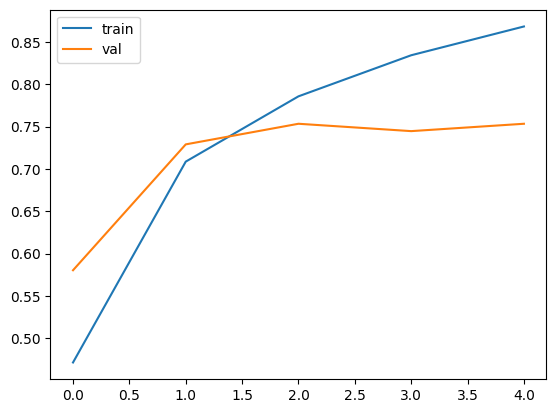

In [28]:
# import matplotlib.pyplot as plot_report

plot_report(xlm_roberta_reports)

In [29]:
from google.colab import drive
drive.mount('/content/drive')


MessageError: Error: credential propagation was unsuccessful

In [ ]:
torch.save(xlm_roberta_model_instance, "/content/drive/My Drive/emotional-main-model-.pth")


In [30]:
proj_test_df = pd.read_table(f'/content/Project_Test - testset.tsv', header=None)
proj_test_df[1] = proj_test_df[1].map(label_dict)


In [34]:
proj_test_df[0]

0                    این فیلم عالی بود، حس خوبی بهم داد
1                         دلم برای این موقعیت نگران است
2                    امروز هوا خیلی زیباست و من خوشحالم
3          این ماشین اصلاً جواب نمیده، ازش خیلی ناراحتم
4     حالا که این خبرو شنیدم از دلم می‌خواستم بخندم ...
5                          باید به این مشکلات پایان داد
6                         از آخرین اخبار خیلی متعجب شدم
7               امروز خیلی خسته ام و اصلاً خوشحال نیستم
8                      این کار به نظرم اشتباه بزرگی بود
9                      باید به زودی این مشکل را حل کنیم
10                      این کتاب جالب و سرگرم‌کننده است
11               این دستگاه هیچ کاری نمی‌کند، عصبانی‌ام
12                        از دیدن این تصاویر ناراحت شدم
13           فکر می‌کنم امتحان‌ها را نمی‌توانم قبول شوم
14               این موسیقی زیباست و حس خوبی بهم می‌دهد
15            اینجا خیلی خلوت است و احساس تنهایی می‌کنم
16               این کلیپ خنده‌داری بود و من خوشحال شدم
17                  امیدوارم این مشکلات به زودی 

In [38]:
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-large')

test_dataset=TextClassificationDataset(proj_test_df[0],proj_test_df[1],tokenizer,max_length)
test_dataloader = DataLoader(test_dataset, batch_size=33)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

val_accuracy, val_report = evaluate(xlm_roberta_model_instance, test_dataloader, device)


100%|██████████| 1/1 [00:00<00:00,  1.35it/s]


In [40]:
val_accuracy

0.7272727272727273

In [39]:
val_report


'              precision    recall  f1-score   support\n\n           0       1.00      0.20      0.33         5\n           1       0.90      1.00      0.95         9\n           2       1.00      0.75      0.86         4\n           3       1.00      0.50      0.67         2\n           5       1.00      0.40      0.57         5\n           6       0.50      1.00      0.67         8\n\n    accuracy                           0.73        33\n   macro avg       0.90      0.64      0.67        33\nweighted avg       0.85      0.73      0.70        33\n'

In [47]:
import pandas as pd
import chardet
import torch
from torch.utils.data import DataLoader
from transformers import XLMRobertaModel, XLMRobertaTokenizer
label_dict = {
    0: 'OTHER',
    1: 'HAPPY',
    2: 'SURPRISE',
    3: 'FEAR',
    4: 'HATE',
    5: 'ANGRY',
    6: 'SAD',
}
def get_sample_tweets():
    # Replace this with your actual code to fetch tweets from Twitter API
    # For now, using a sample list of tweets
    # sample_tweets = [
    #     "تعداد بایاس ها برابر است با تعداد فیلترها  OTHER",
    # ]
    sample_tweets = [
        "تعداد بایاس ها برابر است با تعداد فیلتره	OTHER",
        # "دلم برای این موقعیت نگران است	FEAR",
        # "امروز هوا خیلی زیباست و من خوشحالم	HAPPY",
        # "این ماشین اصلاً جواب نمیده، ازش خیلی ناراحتم	SAD",
        # "حالا که این خبرو شنیدم از دلم می‌خواستم بخندم یا گریه کنم؟	SURPRISE",
        # "باید به این مشکلات پایان داد	OTHER",
        # "از آخرین اخبار خیلی متعجب شدم	SURPRISE",
        # "امروز خیلی خسته ام و اصلاً خوشحال نیستم	SAD",
        # "این کار به نظرم اشتباه بزرگی بود	ANGRY",
        # "باید به زودی این مشکل را حل کنیم	OTHER",
        # "این کتاب جالب و سرگرم‌کننده است	HAPPY",
        # "این دستگاه هیچ کاری نمی‌کند، عصبانی‌ام	ANGRY",
        # "از دیدن این تصاویر ناراحت شدم	SAD",
        # "فکر می‌کنم امتحان‌ها را نمی‌توانم قبول شوم	FEAR",
        # "این موسیقی زیباست و حس خوبی بهم می‌دهد	HAPPY",
        # "اینجا خیلی خلوت است و احساس تنهایی می‌کنم	SAD",
        # "این کلیپ خنده‌داری بود و من خوشحال شدم	HAPPY",
        # "امیدوارم این مشکلات به زودی حل شوند	OTHER",
        # "این جشن تولد خیلی خوب بود و من خوشحالم	HAPPY",
        # "از این اظهارنظرها خیلی خوشحال شدم	HAPPY",
        # "این وضعیت جدید برام ناخوشایند است	OTHER",
        # "دلم برای این فرد تنگ شده است	SAD",
        # "این قهری و ناراضی بودن از همه چیز خسته‌کننده است	ANGRY",
        # "این مطلب جدید من را به شدت متعجب کرد	SURPRISE",
        # "این کتاب اطلاعات خوبی ارائه داد	OTHER",
        # "این موسیقی غم‌انگیز است و حالت ناراحتی بهم داد	SAD",
        # "اعصابم خورد است	ANGRY",
        # "این وضعیت غیرقابل تحمل است و باید تغییر کند	ANGRY",
        # "امروز رفتم مثلا خريد بعد ماه ها:))) رفتم بازار و هيچي نخريدم جز يه عينك و يه بلوز سكته ناقص و زدم.اين حجم از گروني واقعا برگ ريزونه:((( از لباساتون و وسايلتون به خوبي مراقبت كنيد:(((	SAD",
        # "هی آدمو ناراحت میکنن بعد میگن \"ناراحت نشو حالا\" :((( خو مگه کرم داری؟ دله دیگه میشکنه	SAD",
        # "مژده جون \"پس مژه بزن که بریزه اشک شادی\"	HAPPY",
        # "مبارک  باشه،چه عجب بالاخره یکی از فالور ها برنده شد?????????????????????✅✅✅	HAPPY",
        # "اولین نشست اجلاس صلح پاریس همزمان با صدومین سالگرد پایان جنگ جهانی اول برگزار شدکه 70کشورجهان شرکت کردند -چرا #ایران که 8تا10میلیون کشته داد دعوت نشد؟!! - #دیپلماسی_عمومی وزارت خارجه ما درواقعه ای که یک سوم جمعیت مارا به کشتن داد،،کجاست؟!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! -عجیبه	SURPRISE"
    ]
    return sample_tweets

# # from transformers import XLMRobertaModel, XLMRobertaTokenizer
# from sklearn.metrics import accuracy_score


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-large')



# Predict emotions for each tweet
predicted_labels = []
true_labels = []  # You need to have the true labels for the tweets
samples = get_sample_tweets()
for sample in samples:
    text_raw, true_label = sample.split("\t")
    label, predictions = predict_emoji([text_raw], xlm_roberta_model_instance, tokenizer, device, label_dict)
    print(label)
    predicted_labels.append(label)
    true_labels.append(true_label)  # Add the true label for the tweet

# Calculate accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy}")



OTHER
Accuracy: 1.0


## Using roberta

*   List item
*   List item



# Test with new dataset group texting and add tweeter api for work real


In the previous experiment we find that parsbert LM is the best langauge model
for this task, So we add extra data to it and train it again.

In [ ]:
from ntscraper import Nitter

In [ ]:
# scraper = Nitter(0)

In [ ]:
# tweets = scraper.get_tweets("Kimiya_Hosseini", mode = 'user', number=10)

In [ ]:
# final_tweets = []
# for x in tweets['tweets']:
#     data = [x['link'], x['text'],x['date'],x['stats']['likes'],x['stats']['comments']]
#     final_tweets.append(data)

In [ ]:
# import pandas as pd

# dat = pd.DataFrame(final_tweets, columns =['twitter_link','text','date','likes','comments'])

In [ ]:
# dat

In [ ]:
# from ntscraper import Nitter
# import pandas as pd

# # List of IDs
# id_list = ["SharifiZarchi", "Kimiya_Hosseini"]  # replace with your IDs

# scraper = Nitter(0)
# final_tweets = []

# # Loop through each ID in the list
# for id in id_list:
#     tweets = scraper.get_tweets(id, mode='user', number=10)
#     if tweets is not None:  # Check if tweets is not None
#         for x in tweets['tweets']:
#             data = [x['link'], x['text'], x['date'], x['stats']['likes'], x['stats']['comments']]
#             final_tweets.append(data)
#     else:
#         print(f"Could not fetch tweets for ID: {id}")
# # Create a DataFrame
# dat = pd.DataFrame(final_tweets, columns=['twitter_link', 'text', 'date', 'likes', 'comments'])


In [ ]:
# dat

In [ ]:
# import torch
# from torch.utils.data import DataLoader
# from transformers import XLMRobertaModel, XLMRobertaTokenizer
# # Emotion prediction
# label_dict = {
#     0: 'OTHER',
#     1: 'HAPPY',
#     2: 'SURPRISE',
#     3: 'FEAR',
#     4: 'HATE',
#     5: 'ANGRY',
#     6: 'SAD',
# }

# tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-large')

# # Predict emotions for each tweet
# for tweet in dat['text']:
#     label, predictions = predict_emoji([tweet], xlm_roberta_model_instance, tokenizer, device, label_dict)
#     print(f"Tweet: {tweet}")
#     print("Predicted Label:", label)
#     print("Predictions:", predictions)
#     print("\n")

In [ ]:
from ntscraper import Nitter
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import XLMRobertaModel, XLMRobertaTokenizer

# Define the get_tweets function
def get_tweets(name, modes, no):
    scraper = Nitter(0)
    tweets = scraper.get_tweets(name, mode=modes, number=no)
    final_tweets = []
    for x in tweets['tweets']:
        data = [name, x['link'], x['text'], x['date'], x['stats']['likes'], x['stats']['comments']]
        final_tweets.append(data)
    dat = pd.DataFrame(final_tweets, columns=['user_id', 'twitter_link', 'text', 'date', 'likes', 'comments'])
    return dat

# List of IDs
id_list = ["SharifiZarchi", "Kimiya_Hosseini"]

# Emotion prediction
label_dict = {
    0: 'OTHER',
    1: 'HAPPY',
    2: 'SURPRISE',
    3: 'FEAR',
    4: 'HATE',
    5: 'ANGRY',
    6: 'SAD',
}

tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-large')

# Predict emotions for each tweet from each ID
for id in id_list:
    dat = get_tweets(id, 'user', 10)
    for index, row in dat.iterrows():
        tweet = row['text']
        label, predictions = predict_emoji([tweet], xlm_roberta_model_instance, tokenizer, device, label_dict)
        print(f"User ID: {row['user_id']}")
        print(f"Tweet: {tweet}")
        print("Predicted Label:", label)
        print("Predictions:", predictions)
        print("\n")


In [ ]:
from ntscraper import Nitter
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import XLMRobertaModel, XLMRobertaTokenizer

# Define the get_tweets function
def get_tweets(name, modes, no):
    scraper = Nitter(0)
    tweets = scraper.get_tweets(name, mode=modes, number=no)
    final_tweets = []
    for x in tweets['tweets']:
        data = [name, x['link'], x['text'], x['date'], x['stats']['likes'], x['stats']['comments']]
        final_tweets.append(data)
    dat = pd.DataFrame(final_tweets, columns=['user_id', 'twitter_link', 'text', 'date', 'likes', 'comments'])
    return dat

# List of IDs
id_list = ["SharifiZarchi", "Kimiya_Hosseini"]

# Emotion prediction
label_dict = {
    0: 'OTHER',
    1: 'HAPPY',
    2: 'SURPRISE',
    3: 'FEAR',
    4: 'HATE',
    5: 'ANGRY',
    6: 'SAD',
}

tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-large')

# Predict emotions for each user's tweets as a whole
for id in id_list:
    dat = get_tweets(id, 'hashtag', 10)
    user_tweets = dat['text'].tolist()
    label, predictions = predict_emoji(user_tweets, xlm_roberta_model_instance, tokenizer, device, label_dict)
    print(f"User ID: {id}")
    print("Predicted Label:", label)
    print("Predictions:", predictions)
    print("\n")
